# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

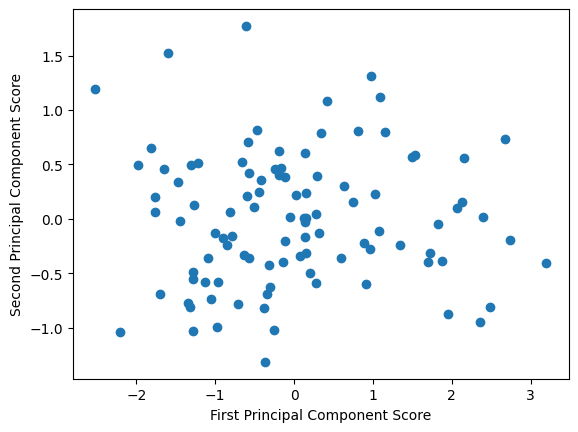

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

Their first principal component score of the outliers in upperleft is low, below 0 and their second principal component score is highabove 1.0 as seen on the scatterplot . 
Series 3: PC1 has a large positive loading on ser3 (0.752), and PC2 has a large negative loading on ser3 (-0.659). A point that is low on PC1 and high on PC2 is pointing toward low ser3 values. So these outliers likely have notably low series_3 values.

Series 1 and Series 2: Because of how they were created: series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points)) has small noise (scale=0.1). They're nearly proportional to each other, so they move together and PCA can't easily distinguish between them.

Advantages: It reduces three dimensions to two while capturing ~99% of the variance (0.799 + 0.190).

Disadvantages: You lose the ability to trace back to individual original variables easily as the third component 1% variance is not able to be represented. 

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [2]:
df_credit = pd.read_csv("credit_risk_dataset.csv", sep=',')

df_encoded = pd.get_dummies(df_credit, 
                             columns= ['loan_intent', 
                                      'loan_grade',
                                      'person_home_ownership',
                                       'cb_person_default_on_file'],
                             prefix=['intent',   
                                     'grade', 
                                     'ownership',
                                     'default_file'])

df_credit_clean = df_encoded[
    (df_encoded['person_age'].between(20,85)) &
    (df_encoded['person_income'].between(0,200000)) & 
    (df_encoded['loan_amnt'].between(5000, 200000)) &
    (df_encoded['person_emp_length'].between(0,40))
].copy()

df_credit_clean.iloc[0:5]

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,intent_DEBTCONSOLIDATION,intent_EDUCATION,...,grade_D,grade_E,grade_F,grade_G,ownership_MORTGAGE,ownership_OTHER,ownership_OWN,ownership_RENT,default_file_N,default_file_Y
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,False,False,False,False,True,False,False,False,True,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,False,False,False,False,False,False,False,True,True,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,False,False,False,False,False,False,False,True,False,True
6,26,77100,8.0,35000,12.42,1,0.45,3,False,True,...,False,False,False,False,False,False,False,True,True,False
7,24,78956,5.0,35000,11.11,1,0.44,4,False,False,...,False,False,False,False,False,False,False,True,True,False


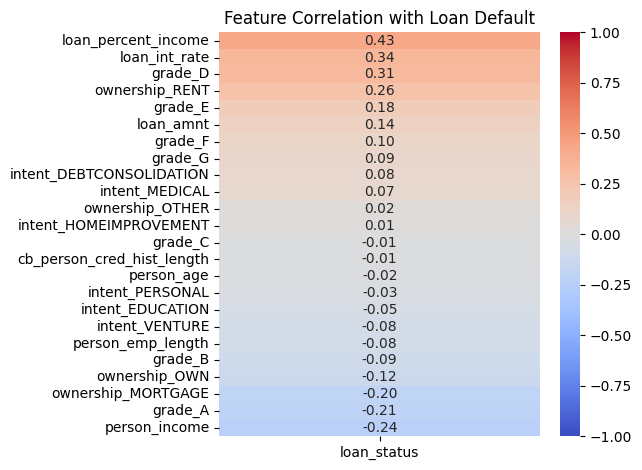

In [3]:
cols_to_drop = ['default_file_Y', 'default_file_N']

credit_corr = (df_credit_clean
               .drop(cols_to_drop, axis=1)  
               .corr(numeric_only=True)) 
loan_status_corr = (credit_corr[['loan_status']]
                    .drop('loan_status', axis=0) 
                    .sort_values('loan_status', ascending=False))

sns.heatmap(loan_status_corr, annot=True, fmt='.2f',
            vmax=1, vmin=-1, center=0, cmap='coolwarm')
plt.title('Feature Correlation with Loan Default')
plt.tight_layout()

ValueError: Could not interpret value `loan_status_label` for `hue`. An entry with this name does not appear in `data`.

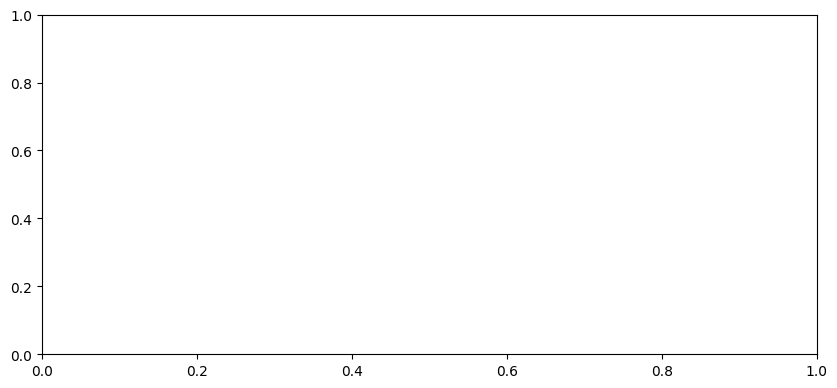

In [4]:
maxbubble = 200
df_sample = df_credit_clean.sample(n=500, random_state=42)

df_credit_clean['loan_status_label'] = df_credit_clean['loan_status'].map({0: 'No Default', 1: 'Default'})

# Bubble Size by Interest Rate
max_int_rate = df_credit_clean['loan_int_rate'].max()
min_int_rate = df_credit_clean['loan_int_rate'].min()

plt.figure(figsize=(10, 15))
plt.subplot(3, 1, 1)
plt.subplot(3, 1, 1)
ax = sns.scatterplot(data=df_sample, x='person_income', y='loan_amnt',
                     size='loan_int_rate', hue='loan_status_label',
                     sizes=(min_int_rate / max_int_rate * maxbubble, maxbubble), alpha=0.6)
ax.set_xlabel("Person Income")
ax.set_ylabel("Loan Amount")
plt.title("Bubble size by Interest Rate")
ax.legend(loc="upper left")

# Bubble Size by Loan Percent Income
max_pct = df_credit_clean['loan_percent_income'].max()
min_pct = df_credit_clean['loan_percent_income'].min()

plt.subplot(3, 1, 2)
ax = sns.scatterplot(data=df_sample, x='loan_amnt', y='loan_int_rate',
                     size='loan_percent_income', hue='loan_status_label',
                     sizes=(min_pct / max_pct * maxbubble, maxbubble), alpha=0.6)
ax.set_xlabel("Loan Amount")
ax.set_ylabel("Interest Rate")
plt.title("Bubble size by Debt-to-Income")
ax.legend(loc="upper left")

# Bubble Size by Loan Amount
max_loan = df_credit_clean['loan_amnt'].max()
min_loan = df_credit_clean['loan_amnt'].min()

plt.subplot(3, 1, 3)
ax = sns.scatterplot(df_sample, x='person_age', y='cb_person_cred_hist_length',
                     size='loan_amnt', hue='loan_status_label',
                     sizes=(min_loan / max_loan * maxbubble, maxbubble), alpha=0.6)
ax.set_xlabel("Person Age")
ax.set_ylabel("Credit History Length")
plt.title("Bubble size by Loan Amount")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

There are still outliers even with the filters that were applied. 

In second plot are at some outliers represented in the sample taken represented by loan amount over 30,000, interest rate over 10%, loan percent income over 45% seen on the far right of Bubble Size by Debt to Income.
The bigger bubbles, higher debt-to-income, also tend to be orange, which makes sense for credit risk.

The third bubble plot also shows some potential outliers over the age 50 with credit histories above 20, with loan amounts less then 20000. These outliers make sense as the data is dense for ages 20-30. It is also not common for someone that old, with that much credit history to want to borrow such a small loan amount. That age groups income is higher.



In [ ]:
from sklearn import decomposition
from sklearn.preprocessing import StandardScaler

df_credit_clean = df_credit_clean.dropna().copy()

df_features = df_credit_clean.drop(columns=['loan_status', 'loan_status_label'])

# Standardize
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_features), columns=df_features.columns)

# Fit PCA with all components
pca = decomposition.PCA(n_components=20)
pca.fit(df_scaled)

# Print explained variance
print(f"Explained variance ratio:\n{pca.explained_variance_ratio_}")

# Print components
#print(f"\nComponents\n:{pca.components_}")


Explained variance ratio:
[0.13067833 0.09064596 0.07294203 0.06753003 0.0541359  0.05078463
 0.04703505 0.04671862 0.04640899 0.04539446 0.0432319  0.04220094
 0.03961373 0.03899702 0.03850799 0.03812472 0.03708251 0.03247049
 0.02706696 0.00467644]


PC1 captures 13.07% variance, which is pretty low. The dataset is high-dimensional and no single direction that summarizes most of the variation. 


You could represent the data using only PC1, but you'd be throwing away ~87% of the variance, so it would not be a proper summary.

In [ ]:
from sklearn import linear_model
from sklearn import metrics

linreg = linear_model.LinearRegression()
linreg.fit(df_credit_clean[['loan_amnt', 'person_income']], df_credit_clean['loan_percent_income'])
loan_preds = linreg.predict(df_credit_clean[['loan_amnt', 'person_income']])
loan_mean = metrics.mean_squared_error(loan_preds, df_credit_clean['loan_percent_income'])

print(f'Loan Prediction: {loan_mean}')

Loan Prediction: 0.002439082178396242


The MSE is low (0.0024) close to 0 as the loan percent income is most directly dervied from loan_amnt feature divided by the person income feature.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

In [ ]:
df_FDIC_loan = pd.read_excel('FDIC-2025-Q3.xlsx', sheet_name='Loan Performance', header=None)

quarters = df_FDIC_loan.iloc[0, 1:]   
metrics = df_FDIC_loan.iloc[1:, 0]         
data = df_FDIC_loan.iloc[1:, 1:]  

df_loan_clean = data.T.copy()
df_loan_clean.columns = metrics.values
df_loan_clean.index = quarters.values
df_loan_clean = df_loan_clean.reset_index().rename(columns={'index': 'Quarter'})
df_loan_clean.columns = df_loan_clean.columns.str.strip()
df_loan_clean = df_loan_clean.loc[:, ~df_loan_clean.columns.duplicated()]

(f'\nNulls:\n{df_loan_clean.isnull().sum()}')

cols_keep = ['Quarter',
             '30-89 day past due rate', 
             'Noncurrent rate', 
             'Total charge-offs', 
             'Net charge-off rate',
             'Credit cards',                    
             'Other loans to individuals',      
             'Agricultural production loans',   
             'Loans to depository institutions']

df_loan_default = df_loan_clean[cols_keep].copy()

# Only convert columns after Quarter
numeric_cols = cols_keep[1:]
for col in numeric_cols:
    df_loan_default[col] = pd.to_numeric(df_loan_default[col], errors='coerce')

# Date columns
df_loan_default['DATE'] = pd.to_datetime(df_loan_default['Quarter'], format='mixed')
df_loan_default['year'] = df_loan_default['DATE'].dt.year
df_loan_default['quarter'] = df_loan_default['DATE'].dt.quarter


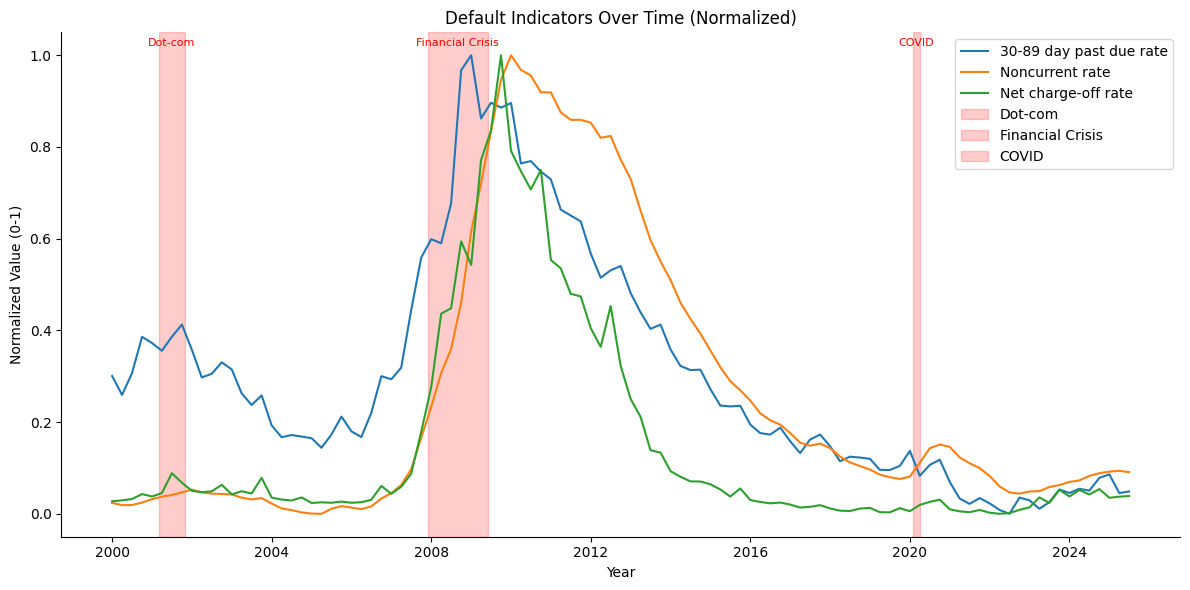

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

scaler = MinMaxScaler()
cols = ['30-89 day past due rate', 'Noncurrent rate', 'Net charge-off rate']

df_scaled = pd.DataFrame(
    scaler.fit_transform(df_loan_default[cols]), 
    columns=cols)
df_scaled['DATE'] = df_loan_default['DATE'].values

for col in cols:
    ax.plot(df_scaled['DATE'], df_scaled[col], label=col)

# Shade recession periods
recessions = [
    ('2001-03-01', '2001-11-01', 'Dot-com'),
    ('2007-12-01', '2009-06-01', 'Financial Crisis'),
    ('2020-02-01', '2020-04-01', 'COVID')
]

for start, end, label in recessions:
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), 
               alpha=0.2, color='red', label=label)
    # Add label on top of shaded area
    mid = pd.to_datetime(start) + (pd.to_datetime(end) - pd.to_datetime(start)) / 2
    ax.text(mid, 1.02, label, ha='center', fontsize=8, color='red')

plt.title('Default Indicators Over Time (Normalized)')
plt.xlabel('Year')
plt.ylabel('Normalized Value (0-1)')
plt.legend(loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

This is similar to figure 5.7 on page 142 labeling relevant financal periods within the period of 2000 to 2026. 